### Магистратура, 2 семестр
### Дисциплина: Высокопроизводительные вычисления
### Лабораторная работа №4 (Bilateral)
### Выполнил: 6133-010402D Журавлев Н.С.

### Проверка GPU и CUDA

In [1]:
!nvidia-smi
!nvcc --version

Mon Apr 27 12:23:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### CUDA/C++ код лабораторной

In [2]:
%%writefile bilateral_filter.cu
#include <cuda_runtime.h>

#include <algorithm>
#include <chrono>
#include <cmath>
#include <cstdint>
#include <cstdlib>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <numeric>
#include <string>
#include <vector>

#define CUDA_CHECK(call)                                                        \
    do {                                                                        \
        cudaError_t err__ = (call);                                             \
        if (err__ != cudaSuccess) {                                             \
            std::cerr << "CUDA error at " << __FILE__ << ":" << __LINE__        \
                      << " -> " << cudaGetErrorString(err__) << std::endl;      \
            std::exit(EXIT_FAILURE);                                            \
        }                                                                       \
    } while (0)

#pragma pack(push, 1)
struct BMPFileHeader {
    uint16_t bfType;
    uint32_t bfSize;
    uint16_t bfReserved1;
    uint16_t bfReserved2;
    uint32_t bfOffBits;
};

struct BMPInfoHeader {
    uint32_t biSize;
    int32_t  biWidth;
    int32_t  biHeight;
    uint16_t biPlanes;
    uint16_t biBitCount;
    uint32_t biCompression;
    uint32_t biSizeImage;
    int32_t  biXPelsPerMeter;
    int32_t  biYPelsPerMeter;
    uint32_t biClrUsed;
    uint32_t biClrImportant;
};
#pragma pack(pop)

struct GpuTimingStats {
    float kernelAvgMs = 0.0f;
    float kernelMinMs = 0.0f;
    float kernelMaxMs = 0.0f;
    float kernelStdMs = 0.0f;
    double setupAndCopyToDeviceMs = 0.0;
    double copyToHostMs = 0.0;
    double estimatedTotalOneRunMs = 0.0;
};

static unsigned char clampToByte(float value) {
    if (value < 0.0f) return 0;
    if (value > 255.0f) return 255;
    return static_cast<unsigned char>(value + 0.5f);
}

bool readBMPGray(const std::string& filename,
                 std::vector<unsigned char>& data,
                 int& width,
                 int& height) {
    std::ifstream in(filename, std::ios::binary);
    if (!in) {
        std::cerr << "Cannot open input BMP file: " << filename << std::endl;
        return false;
    }

    BMPFileHeader fileHeader{};
    BMPInfoHeader infoHeader{};

    in.read(reinterpret_cast<char*>(&fileHeader), sizeof(fileHeader));
    in.read(reinterpret_cast<char*>(&infoHeader), sizeof(infoHeader));

    if (!in) {
        std::cerr << "Cannot read BMP headers." << std::endl;
        return false;
    }

    if (fileHeader.bfType != 0x4D42) {
        std::cerr << "Input file is not BMP." << std::endl;
        return false;
    }

    if (infoHeader.biSize < 40) {
        std::cerr << "Unsupported BMP header size." << std::endl;
        return false;
    }

    if (infoHeader.biCompression != 0) {
        std::cerr << "Only uncompressed BMP is supported." << std::endl;
        return false;
    }

    if (!(infoHeader.biBitCount == 8 ||
          infoHeader.biBitCount == 24 ||
          infoHeader.biBitCount == 32)) {
        std::cerr << "Only 8-bit, 24-bit and 32-bit BMP are supported." << std::endl;
        return false;
    }

    if (infoHeader.biWidth <= 0 || infoHeader.biHeight == 0) {
        std::cerr << "Invalid BMP dimensions." << std::endl;
        return false;
    }

    width = infoHeader.biWidth;
    height = infoHeader.biHeight > 0 ? infoHeader.biHeight : -infoHeader.biHeight;
    const bool topDown = infoHeader.biHeight < 0;

    std::vector<unsigned char> paletteGray(256);
    for (int i = 0; i < 256; ++i) {
        paletteGray[i] = static_cast<unsigned char>(i);
    }

    if (infoHeader.biBitCount == 8) {
        uint32_t colors = infoHeader.biClrUsed ? infoHeader.biClrUsed : 256;
        colors = std::min(colors, 256u);

        in.seekg(sizeof(BMPFileHeader) + infoHeader.biSize, std::ios::beg);

        for (uint32_t i = 0; i < colors; ++i) {
            unsigned char bgra[4]{};
            in.read(reinterpret_cast<char*>(bgra), 4);

            const unsigned char b = bgra[0];
            const unsigned char g = bgra[1];
            const unsigned char r = bgra[2];

            paletteGray[i] = static_cast<unsigned char>(
                0.299f * r + 0.587f * g + 0.114f * b + 0.5f
            );
        }
    }

    const int bytesPerPixel = infoHeader.biBitCount / 8;
    const int rowStride = ((width * bytesPerPixel + 3) / 4) * 4;

    data.assign(static_cast<size_t>(width) * height, 0);

    std::vector<unsigned char> row(rowStride);

    in.seekg(fileHeader.bfOffBits, std::ios::beg);

    for (int fileRow = 0; fileRow < height; ++fileRow) {
        in.read(reinterpret_cast<char*>(row.data()), rowStride);

        if (!in) {
            std::cerr << "Cannot read BMP pixel data." << std::endl;
            return false;
        }

        const int y = topDown ? fileRow : (height - 1 - fileRow);

        for (int x = 0; x < width; ++x) {
            unsigned char grayValue = 0;

            if (infoHeader.biBitCount == 8) {
                grayValue = paletteGray[row[x]];
            } else if (infoHeader.biBitCount == 24) {
                const int p = x * 3;
                const unsigned char b = row[p + 0];
                const unsigned char g = row[p + 1];
                const unsigned char r = row[p + 2];

                grayValue = static_cast<unsigned char>(
                    0.299f * r + 0.587f * g + 0.114f * b + 0.5f
                );
            } else {
                const int p = x * 4;
                const unsigned char b = row[p + 0];
                const unsigned char g = row[p + 1];
                const unsigned char r = row[p + 2];

                grayValue = static_cast<unsigned char>(
                    0.299f * r + 0.587f * g + 0.114f * b + 0.5f
                );
            }

            data[static_cast<size_t>(y) * width + x] = grayValue;
        }
    }

    return true;
}

bool writeBMPGray24(const std::string& filename,
                    const std::vector<unsigned char>& data,
                    int width,
                    int height) {
    if (width <= 0 || height <= 0 ||
        data.size() != static_cast<size_t>(width) * height) {
        std::cerr << "Invalid data for BMP writing." << std::endl;
        return false;
    }

    const int bytesPerPixel = 3;
    const int rowStride = ((width * bytesPerPixel + 3) / 4) * 4;
    const uint32_t imageSize = static_cast<uint32_t>(rowStride * height);

    BMPFileHeader fileHeader{};
    BMPInfoHeader infoHeader{};

    fileHeader.bfType = 0x4D42;
    fileHeader.bfOffBits = sizeof(BMPFileHeader) + sizeof(BMPInfoHeader);
    fileHeader.bfSize = fileHeader.bfOffBits + imageSize;

    infoHeader.biSize = sizeof(BMPInfoHeader);
    infoHeader.biWidth = width;
    infoHeader.biHeight = height;
    infoHeader.biPlanes = 1;
    infoHeader.biBitCount = 24;
    infoHeader.biCompression = 0;
    infoHeader.biSizeImage = imageSize;

    std::ofstream out(filename, std::ios::binary);
    if (!out) {
        std::cerr << "Cannot create output BMP file: " << filename << std::endl;
        return false;
    }

    out.write(reinterpret_cast<const char*>(&fileHeader), sizeof(fileHeader));
    out.write(reinterpret_cast<const char*>(&infoHeader), sizeof(infoHeader));

    std::vector<unsigned char> row(rowStride, 0);

    for (int y = height - 1; y >= 0; --y) {
        std::fill(row.begin(), row.end(), 0);

        for (int x = 0; x < width; ++x) {
            const unsigned char v = data[static_cast<size_t>(y) * width + x];

            row[x * 3 + 0] = v;
            row[x * 3 + 1] = v;
            row[x * 3 + 2] = v;
        }

        out.write(reinterpret_cast<const char*>(row.data()), rowStride);
    }

    return true;
}

void bilateralCPU(const std::vector<unsigned char>& input,
                  std::vector<unsigned char>& output,
                  int width,
                  int height,
                  float sigmaD,
                  float sigmaR) {
    output.resize(static_cast<size_t>(width) * height);

    const float inv2SigmaD2 = 1.0f / (2.0f * sigmaD * sigmaD);
    const float inv2SigmaR2 = 1.0f / (2.0f * sigmaR * sigmaR);

    for (int y = 0; y < height; ++y) {
        for (int x = 0; x < width; ++x) {
            const float center = static_cast<float>(
                input[static_cast<size_t>(y) * width + x]
            );

            float weightedSum = 0.0f;
            float weightNorm = 0.0f;

            for (int dy = -1; dy <= 1; ++dy) {
                for (int dx = -1; dx <= 1; ++dx) {
                    int xx = x + dx;
                    int yy = y + dy;

                    if (xx < 0) xx = 0;
                    if (yy < 0) yy = 0;
                    if (xx >= width) xx = width - 1;
                    if (yy >= height) yy = height - 1;

                    const float value = static_cast<float>(
                        input[static_cast<size_t>(yy) * width + xx]
                    );

                    const float spatialWeight = std::exp(
                        -static_cast<float>(dx * dx + dy * dy) * inv2SigmaD2
                    );

                    const float diff = value - center;

                    const float rangeWeight = std::exp(
                        -(diff * diff) * inv2SigmaR2
                    );

                    const float weight = spatialWeight * rangeWeight;

                    weightedSum += weight * value;
                    weightNorm += weight;
                }
            }

            output[static_cast<size_t>(y) * width + x] =
                clampToByte(weightedSum / weightNorm);
        }
    }
}

__device__ __forceinline__ unsigned char clampToByteDevice(float value) {
    if (value < 0.0f) return 0;
    if (value > 255.0f) return 255;
    return static_cast<unsigned char>(value + 0.5f);
}

__global__ void bilateralKernel(cudaTextureObject_t texObj,
                                unsigned char* output,
                                int width,
                                int height,
                                float sigmaD,
                                float sigmaR) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height) {
        return;
    }

    const float inv2SigmaD2 = 1.0f / (2.0f * sigmaD * sigmaD);
    const float inv2SigmaR2 = 1.0f / (2.0f * sigmaR * sigmaR);

    const float center = static_cast<float>(
        tex2D<unsigned char>(texObj, x + 0.5f, y + 0.5f)
    );

    float weightedSum = 0.0f;
    float weightNorm = 0.0f;

    // 9-точечная маска: 3 x 3 окрестности
    for (int dy = -1; dy <= 1; ++dy) {
        for (int dx = -1; dx <= 1; ++dx) {
            int xx = x + dx;
            int yy = y + dy;

            // Пропущенные значения для граничных строк и столбцов берутся из ближайших пикселей
            if (xx < 0) xx = 0;
            if (yy < 0) yy = 0;
            if (xx >= width) xx = width - 1;
            if (yy >= height) yy = height - 1;

            const float value = static_cast<float>(
                tex2D<unsigned char>(texObj, xx + 0.5f, yy + 0.5f)
            );

            const float spatialWeight = expf(
                -static_cast<float>(dx * dx + dy * dy) * inv2SigmaD2
            );

            const float diff = value - center;

            const float rangeWeight = expf(
                -(diff * diff) * inv2SigmaR2
            );

            const float weight = spatialWeight * rangeWeight;

            weightedSum += weight * value;
            weightNorm += weight;
        }
    }

    output[static_cast<size_t>(y) * width + x] =
        clampToByteDevice(weightedSum / weightNorm);
}

static float meanValue(const std::vector<float>& values) {
    if (values.empty()) return 0.0f;
    const float sum = std::accumulate(values.begin(), values.end(), 0.0f);
    return sum / static_cast<float>(values.size());
}

static float stdValue(const std::vector<float>& values, float mean) {
    if (values.size() <= 1) return 0.0f;

    float sum = 0.0f;

    for (float v : values) {
        const float d = v - mean;
        sum += d * d;
    }

    return std::sqrt(sum / static_cast<float>(values.size() - 1));
}

void bilateralGPU(const std::vector<unsigned char>& input,
                  std::vector<unsigned char>& output,
                  int width,
                  int height,
                  float sigmaD,
                  float sigmaR,
                  int measuredRuns,
                  int warmupRuns,
                  GpuTimingStats& stats) {
    output.resize(static_cast<size_t>(width) * height);

    cudaChannelFormatDesc channelDesc = cudaCreateChannelDesc<unsigned char>();

    cudaArray_t cudaArrayInput = nullptr;
    cudaTextureObject_t texObj = 0;
    unsigned char* dOutput = nullptr;

    const size_t imageBytes =
        static_cast<size_t>(width) * height * sizeof(unsigned char);

    const auto setupStart = std::chrono::high_resolution_clock::now();

    CUDA_CHECK(cudaMallocArray(
        &cudaArrayInput,
        &channelDesc,
        width,
        height
    ));

    CUDA_CHECK(cudaMemcpy2DToArray(
        cudaArrayInput,
        0,
        0,
        input.data(),
        static_cast<size_t>(width) * sizeof(unsigned char),
        static_cast<size_t>(width) * sizeof(unsigned char),
        height,
        cudaMemcpyHostToDevice
    ));

    cudaResourceDesc resourceDesc{};
    resourceDesc.resType = cudaResourceTypeArray;
    resourceDesc.res.array.array = cudaArrayInput;

    cudaTextureDesc textureDesc{};
    textureDesc.addressMode[0] = cudaAddressModeClamp;
    textureDesc.addressMode[1] = cudaAddressModeClamp;
    textureDesc.filterMode = cudaFilterModePoint;
    textureDesc.readMode = cudaReadModeElementType;
    textureDesc.normalizedCoords = 0;

    CUDA_CHECK(cudaCreateTextureObject(
        &texObj,
        &resourceDesc,
        &textureDesc,
        nullptr
    ));

    CUDA_CHECK(cudaMalloc(&dOutput, imageBytes));
    CUDA_CHECK(cudaDeviceSynchronize());

    const auto setupStop = std::chrono::high_resolution_clock::now();

    stats.setupAndCopyToDeviceMs =
        std::chrono::duration<double, std::milli>(setupStop - setupStart).count();

    const dim3 block(16, 16);
    const dim3 grid(
        (width + block.x - 1) / block.x,
        (height + block.y - 1) / block.y
    );

    for (int i = 0; i < warmupRuns; ++i) {
        bilateralKernel<<<grid, block>>>(
            texObj,
            dOutput,
            width,
            height,
            sigmaD,
            sigmaR
        );

        CUDA_CHECK(cudaGetLastError());
    }

    CUDA_CHECK(cudaDeviceSynchronize());

    std::vector<float> kernelTimes;
    kernelTimes.reserve(measuredRuns);

    cudaEvent_t startEvent;
    cudaEvent_t stopEvent;

    CUDA_CHECK(cudaEventCreate(&startEvent));
    CUDA_CHECK(cudaEventCreate(&stopEvent));

    for (int i = 0; i < measuredRuns; ++i) {
        CUDA_CHECK(cudaEventRecord(startEvent));

        bilateralKernel<<<grid, block>>>(
            texObj,
            dOutput,
            width,
            height,
            sigmaD,
            sigmaR
        );

        CUDA_CHECK(cudaGetLastError());

        CUDA_CHECK(cudaEventRecord(stopEvent));
        CUDA_CHECK(cudaEventSynchronize(stopEvent));

        float elapsedMs = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&elapsedMs, startEvent, stopEvent));

        kernelTimes.push_back(elapsedMs);
    }

    CUDA_CHECK(cudaEventDestroy(startEvent));
    CUDA_CHECK(cudaEventDestroy(stopEvent));

    stats.kernelAvgMs = meanValue(kernelTimes);
    stats.kernelMinMs = *std::min_element(kernelTimes.begin(), kernelTimes.end());
    stats.kernelMaxMs = *std::max_element(kernelTimes.begin(), kernelTimes.end());
    stats.kernelStdMs = stdValue(kernelTimes, stats.kernelAvgMs);

    const auto copyStart = std::chrono::high_resolution_clock::now();

    CUDA_CHECK(cudaMemcpy(
        output.data(),
        dOutput,
        imageBytes,
        cudaMemcpyDeviceToHost
    ));

    const auto copyStop = std::chrono::high_resolution_clock::now();

    stats.copyToHostMs =
        std::chrono::duration<double, std::milli>(copyStop - copyStart).count();

    stats.estimatedTotalOneRunMs =
        stats.setupAndCopyToDeviceMs + stats.kernelAvgMs + stats.copyToHostMs;

    CUDA_CHECK(cudaDestroyTextureObject(texObj));
    CUDA_CHECK(cudaFree(dOutput));
    CUDA_CHECK(cudaFreeArray(cudaArrayInput));
}

void compareImages(const std::vector<unsigned char>& a,
                   const std::vector<unsigned char>& b,
                   int& maxAbsDiff,
                   double& meanAbsDiff) {
    maxAbsDiff = 0;
    long long sumAbsDiff = 0;

    for (size_t i = 0; i < a.size(); ++i) {
        const int diff = std::abs(static_cast<int>(a[i]) - static_cast<int>(b[i]));
        maxAbsDiff = std::max(maxAbsDiff, diff);
        sumAbsDiff += diff;
    }

    meanAbsDiff =
        static_cast<double>(sumAbsDiff) / static_cast<double>(a.size());
}

int main(int argc, char** argv) {
    std::string inputFile = "input.bmp";
    float sigmaD = 1.0f;
    float sigmaR = 30.0f;
    int measuredGpuRuns = 20;
    int warmupGpuRuns = 3;

    if (argc >= 2) {
        inputFile = argv[1];
    }

    if (argc >= 3) {
        sigmaD = std::stof(argv[2]);
    }

    if (argc >= 4) {
        sigmaR = std::stof(argv[3]);
    }

    if (argc >= 5) {
        measuredGpuRuns = std::stoi(argv[4]);
    }

    if (argc >= 6) {
        warmupGpuRuns = std::stoi(argv[5]);
    }

    if (sigmaD <= 0.0f || sigmaR <= 0.0f) {
        std::cerr << "Sigma values must be positive." << std::endl;
        return EXIT_FAILURE;
    }

    if (measuredGpuRuns <= 0) {
        std::cerr << "Number of measured GPU runs must be positive." << std::endl;
        return EXIT_FAILURE;
    }

    if (warmupGpuRuns < 0) {
        std::cerr << "Number of warm-up GPU runs cannot be negative." << std::endl;
        return EXIT_FAILURE;
    }

    int deviceCount = 0;
    CUDA_CHECK(cudaGetDeviceCount(&deviceCount));

    if (deviceCount <= 0) {
        std::cerr << "No CUDA device found." << std::endl;
        return EXIT_FAILURE;
    }

    cudaDeviceProp prop{};
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));

    std::vector<unsigned char> input;
    int width = 0;
    int height = 0;

    if (!readBMPGray(inputFile, input, width, height)) {
        return EXIT_FAILURE;
    }

    std::vector<unsigned char> cpuOutput;
    std::vector<unsigned char> gpuOutput;

    const auto cpuStart = std::chrono::high_resolution_clock::now();

    bilateralCPU(
        input,
        cpuOutput,
        width,
        height,
        sigmaD,
        sigmaR
    );

    const auto cpuStop = std::chrono::high_resolution_clock::now();

    const double cpuMs =
        std::chrono::duration<double, std::milli>(cpuStop - cpuStart).count();

    GpuTimingStats gpuStats{};

    bilateralGPU(
        input,
        gpuOutput,
        width,
        height,
        sigmaD,
        sigmaR,
        measuredGpuRuns,
        warmupGpuRuns,
        gpuStats
    );

    if (!writeBMPGray24("output_cpu.bmp", cpuOutput, width, height)) {
        return EXIT_FAILURE;
    }

    if (!writeBMPGray24("output_gpu.bmp", gpuOutput, width, height)) {
        return EXIT_FAILURE;
    }

    int maxAbsDiff = 0;
    double meanAbsDiff = 0.0;

    compareImages(cpuOutput, gpuOutput, maxAbsDiff, meanAbsDiff);

    std::cout << std::fixed << std::setprecision(6);

    std::cout << "CUDA device: " << prop.name << std::endl;
    std::cout << "Input image: " << inputFile << std::endl;
    std::cout << "Image size: " << width << " x " << height << std::endl;
    std::cout << "sigma_d: " << sigmaD << std::endl;
    std::cout << "sigma_r: " << sigmaR << std::endl;
    std::cout << "GPU warm-up runs: " << warmupGpuRuns << std::endl;
    std::cout << "GPU measured runs: " << measuredGpuRuns << std::endl;
    std::cout << std::endl;

    std::cout << "CPU processing time: " << cpuMs << " ms" << std::endl;
    std::cout << "GPU setup and host-to-device time: "
              << gpuStats.setupAndCopyToDeviceMs << " ms" << std::endl;
    std::cout << "GPU kernel average time: "
              << gpuStats.kernelAvgMs << " ms" << std::endl;
    std::cout << "GPU kernel min time: "
              << gpuStats.kernelMinMs << " ms" << std::endl;
    std::cout << "GPU kernel max time: "
              << gpuStats.kernelMaxMs << " ms" << std::endl;
    std::cout << "GPU kernel std time: "
              << gpuStats.kernelStdMs << " ms" << std::endl;
    std::cout << "GPU device-to-host time: "
              << gpuStats.copyToHostMs << " ms" << std::endl;
    std::cout << "GPU estimated total time for one processing: "
              << gpuStats.estimatedTotalOneRunMs << " ms" << std::endl;

    std::cout << std::endl;
    std::cout << "CPU/GPU max absolute difference: " << maxAbsDiff << std::endl;
    std::cout << "CPU/GPU mean absolute difference: " << meanAbsDiff << std::endl;

    std::cout << std::endl;
    std::cout << "Saved files:" << std::endl;
    std::cout << "  output_cpu.bmp" << std::endl;
    std::cout << "  output_gpu.bmp" << std::endl;

    return EXIT_SUCCESS;
}

Writing bilateral_filter.cu


### Компиляция

In [3]:
!nvcc -O3 -std=c++17 bilateral_filter.cu -o bilateral_filter

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


### Функции для загрузки, запусков, таблиц и картинок

In [4]:
from google.colab import files
from PIL import Image
import subprocess
import re
import shutil
import os
import glob
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

def upload_and_prepare_image(image_label):
    uploaded = files.upload()

    if not uploaded:
        raise RuntimeError("Файл не загружен")

    src_name = next(iter(uploaded.keys()))

    img = Image.open(src_name)
    gray = img.convert("L")

    gray.save("input.bmp", format="BMP")
    gray.save(f"input_{image_label}.bmp", format="BMP")

    print(f"Загружен файл: {src_name}")
    print(f"Метка изображения: {image_label}")
    print(f"Размер изображения: {gray.size[0]} x {gray.size[1]}")
    print("Создан файл для CUDA-программы: input.bmp")
    print(f"Сохранена копия: input_{image_label}.bmp")


def extract_float(pattern, text):
    match = re.search(pattern, text)
    if not match:
        raise ValueError(f"Не найдено значение по шаблону: {pattern}")
    return float(match.group(1))


def extract_int(pattern, text):
    match = re.search(pattern, text)
    if not match:
        raise ValueError(f"Не найдено значение по шаблону: {pattern}")
    return int(match.group(1))


def run_experiments_for_current_image(image_label):
    sigma_d = 1.0
    sigma_r_values = [5.0, 15.0, 30.0, 60.0, 120.0]

    gpu_measured_runs = 20
    gpu_warmup_runs = 3

    results = []

    for sigma_r in sigma_r_values:
        print("=" * 90)
        print(f"Run: {image_label}, sigma_d={sigma_d}, sigma_r={sigma_r}")
        print(f"GPU warm-up runs={gpu_warmup_runs}, GPU measured runs={gpu_measured_runs}")
        print("=" * 90)

        completed = subprocess.run(
            [
                "./bilateral_filter",
                "input.bmp",
                str(sigma_d),
                str(sigma_r),
                str(gpu_measured_runs),
                str(gpu_warmup_runs)
            ],
            text=True,
            capture_output=True
        )

        print(completed.stdout)

        if completed.returncode != 0:
            print(completed.stderr)
            raise RuntimeError("CUDA/C++ программа завершилась с ошибкой")

        output_text = completed.stdout

        cpu_time = extract_float(r"CPU processing time:\s+([\d.eE+-]+)", output_text)
        gpu_setup_h2d = extract_float(r"GPU setup and host-to-device time:\s+([\d.eE+-]+)", output_text)
        gpu_kernel_avg = extract_float(r"GPU kernel average time:\s+([\d.eE+-]+)", output_text)
        gpu_kernel_min = extract_float(r"GPU kernel min time:\s+([\d.eE+-]+)", output_text)
        gpu_kernel_max = extract_float(r"GPU kernel max time:\s+([\d.eE+-]+)", output_text)
        gpu_kernel_std = extract_float(r"GPU kernel std time:\s+([\d.eE+-]+)", output_text)
        gpu_d2h = extract_float(r"GPU device-to-host time:\s+([\d.eE+-]+)", output_text)
        gpu_total_est = extract_float(r"GPU estimated total time for one processing:\s+([\d.eE+-]+)", output_text)
        max_diff = extract_int(r"CPU/GPU max absolute difference:\s+(\d+)", output_text)
        mean_diff = extract_float(r"CPU/GPU mean absolute difference:\s+([\d.eE+-]+)", output_text)

        img = Image.open("input.bmp")
        width, height = img.size

        suffix = f"{image_label}_sd{sigma_d}_sr{int(sigma_r)}"

        shutil.copy("input.bmp", f"input_{image_label}.bmp")
        shutil.copy("output_cpu.bmp", f"output_cpu_{suffix}.bmp")
        shutil.copy("output_gpu.bmp", f"output_gpu_{suffix}.bmp")

        results.append({
            "image": image_label,
            "width": width,
            "height": height,
            "pixels": width * height,
            "sigma_d": sigma_d,
            "sigma_r": sigma_r,
            "gpu_warmup_runs": gpu_warmup_runs,
            "gpu_measured_runs": gpu_measured_runs,
            "CPU time, ms": cpu_time,
            "GPU setup + H2D, ms": gpu_setup_h2d,
            "GPU kernel avg, ms": gpu_kernel_avg,
            "GPU kernel min, ms": gpu_kernel_min,
            "GPU kernel max, ms": gpu_kernel_max,
            "GPU kernel std, ms": gpu_kernel_std,
            "GPU D2H, ms": gpu_d2h,
            "GPU estimated total, ms": gpu_total_est,
            "kernel speedup": cpu_time / gpu_kernel_avg,
            "estimated total speedup": cpu_time / gpu_total_est,
            "max abs diff": max_diff,
            "mean abs diff": mean_diff
        })

    df = pd.DataFrame(results)
    df.to_csv(f"results_{image_label}.csv", index=False)

    print(f"Таблица сохранена: results_{image_label}.csv")
    display(df)

    return df


def show_results_for_image(image_label):
    sigma_d = 1.0
    sigma_r_values = [5, 15, 30, 60, 120]

    items = [(f"input_{image_label}.bmp", "Input grayscale BMP")]

    for sigma_r in sigma_r_values:
        items.append((
            f"output_gpu_{image_label}_sd{sigma_d}_sr{sigma_r}.bmp",
            f"GPU bilateral: σd={sigma_d}, σr={sigma_r}"
        ))

    plt.figure(figsize=(18, 10))

    for i, (path, title) in enumerate(items, start=1):
        plt.subplot(2, 3, i)
        plt.imshow(Image.open(path).convert("L"), cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def make_final_archive():
    csv_files = sorted(glob.glob("results_image_*.csv"))

    if csv_files:
        all_results = pd.concat([pd.read_csv(path) for path in csv_files], ignore_index=True)
        all_results.to_csv("results_all.csv", index=False)
        display(all_results)
    else:
        print("Файлы results_image_*.csv пока не найдены")

    files_to_zip = []

    patterns = [
        "input_image_*.bmp",
        "output_cpu_image_*.bmp",
        "output_gpu_image_*.bmp",
        "results_image_*.csv",
        "results_all.csv",
        "bilateral_filter.cu"
    ]

    for pattern in patterns:
        files_to_zip.extend(glob.glob(pattern))

    files_to_zip = sorted(set(files_to_zip))

    with zipfile.ZipFile("bilateral_lab_results.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
        for path in files_to_zip:
            zipf.write(path)

    print("В архив добавлены файлы:")
    for path in files_to_zip:
        print(" ", path)

    files.download("bilateral_lab_results.zip")

### Загрузка 1-го изображения

In [5]:
upload_and_prepare_image("image_1")

Saving manwithnoname-main1.jpg to manwithnoname-main1.jpg
Загружен файл: manwithnoname-main1.jpg
Метка изображения: image_1
Размер изображения: 1600 x 2400
Создан файл для CUDA-программы: input.bmp
Сохранена копия: input_image_1.bmp


### Запуск 5 экспериментов для 1-го изображения

In [6]:
df1 = run_experiments_for_current_image("image_1")

Run: image_1, sigma_d=1.0, sigma_r=5.0
GPU warm-up runs=3, GPU measured runs=20
CUDA device: Tesla T4
Input image: input.bmp
Image size: 1600 x 2400
sigma_d: 1.000000
sigma_r: 5.000000
GPU warm-up runs: 3
GPU measured runs: 20

CPU processing time: 513.207928 ms
GPU setup and host-to-device time: 187.671795 ms
GPU kernel average time: 0.519722 ms
GPU kernel min time: 0.518176 ms
GPU kernel max time: 0.524256 ms
GPU kernel std time: 0.001362 ms
GPU device-to-host time: 0.959567 ms
GPU estimated total time for one processing: 189.151084 ms

CPU/GPU max absolute difference: 1
CPU/GPU mean absolute difference: 0.000002

Saved files:
  output_cpu.bmp
  output_gpu.bmp

Run: image_1, sigma_d=1.0, sigma_r=15.0
GPU warm-up runs=3, GPU measured runs=20
CUDA device: Tesla T4
Input image: input.bmp
Image size: 1600 x 2400
sigma_d: 1.000000
sigma_r: 15.000000
GPU warm-up runs: 3
GPU measured runs: 20

CPU processing time: 511.361093 ms
GPU setup and host-to-device time: 152.791695 ms
GPU kernel ave

,image,width,height,pixels,sigma_d,sigma_r,gpu_warmup_runs,gpu_measured_runs,"CPU time, ms","GPU setup + H2D, ms","GPU kernel avg, ms","GPU kernel min, ms","GPU kernel max, ms","GPU kernel std, ms","GPU D2H, ms","GPU estimated total, ms",kernel speedup,estimated total speedup,max abs diff,mean abs diff
0,image_1,1600,2400,3840000,1.0,5.0,3,20,513.207928,187.671795,0.519722,0.518176,0.524256,0.001362,0.959567,189.151084,987.466238,2.713217,1,0.000002
1,image_1,1600,2400,3840000,1.0,15.0,3,20,511.361093,152.791695,0.344342,0.342016,0.362496,0.004419,0.970240,154.106277,1485.038401,3.318237,1,0.000001
2,image_1,1600,2400,3840000,1.0,30.0,3,20,770.928335,164.440690,0.496170,0.495264,0.498432,0.000852,1.019373,165.956233,1553.758460,4.645371,1,0.000001
3,image_1,1600,2400,3840000,1.0,60.0,3,20,833.798477,173.223770,0.524845,0.521184,0.528192,0.001564,1.038907,174.787522,1588.656607,4.770355,1,0.000001
4,image_1,1600,2400,3840000,1.0,120.0,3,20,511.516875,166.797294,0.452506,0.450912,0.454656,0.000872,1.031533,168.281333,1130.409044,3.039653,1,0.000000


### Результаты для 1-го изображения

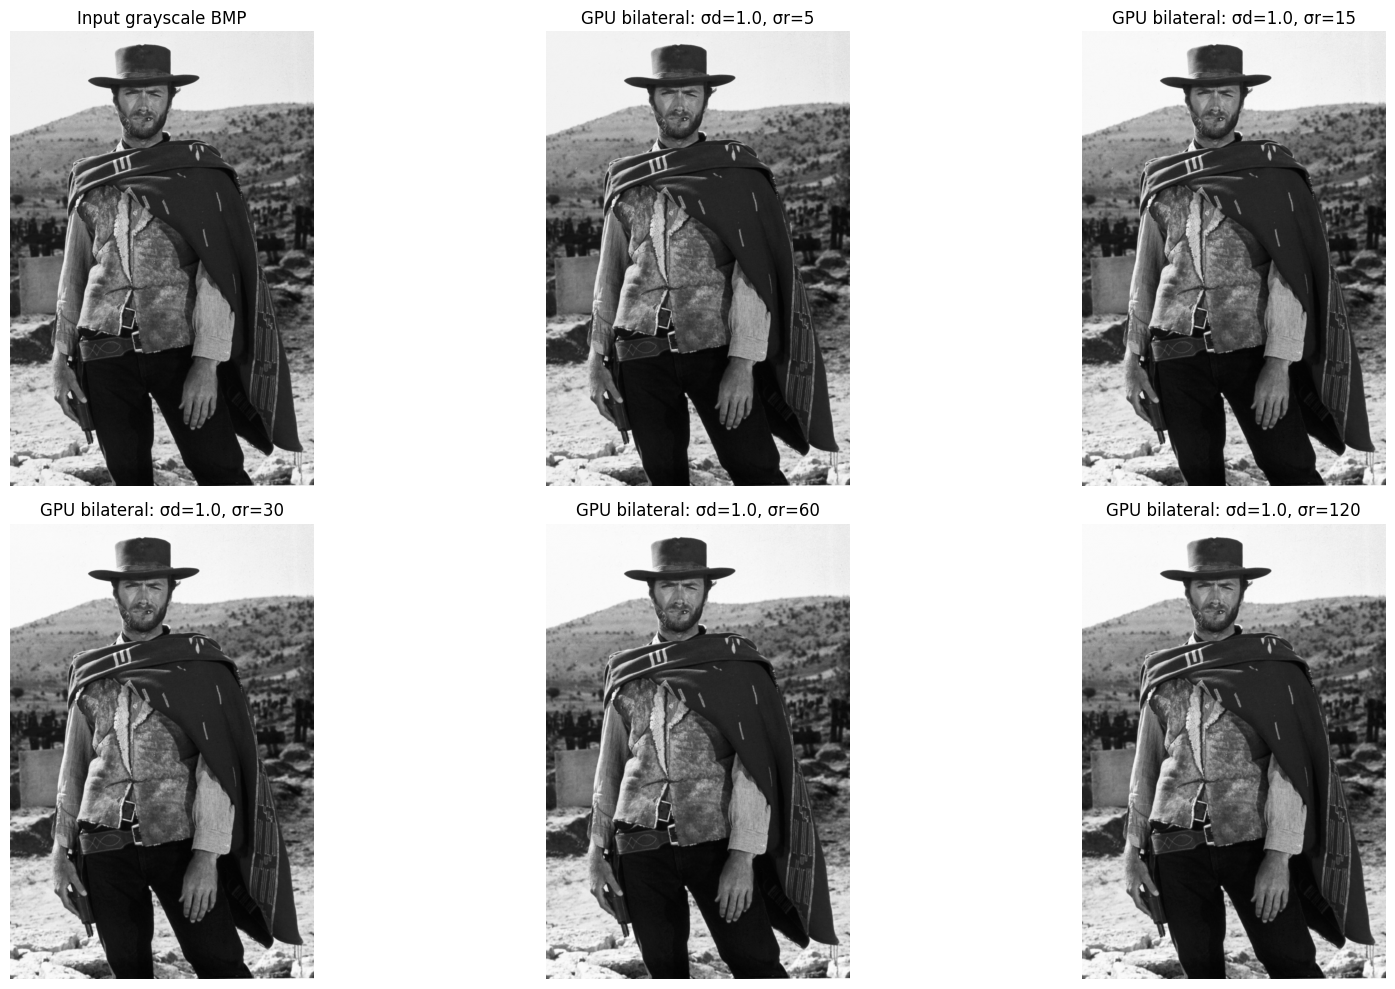

In [7]:
show_results_for_image("image_1")

### Загрузить 2-ое изображение

In [8]:
upload_and_prepare_image("image_2")

Saving 5a993046bcf9aacbecc3b81787aedafe.jpg to 5a993046bcf9aacbecc3b81787aedafe.jpg
Загружен файл: 5a993046bcf9aacbecc3b81787aedafe.jpg
Метка изображения: image_2
Размер изображения: 736 x 477
Создан файл для CUDA-программы: input.bmp
Сохранена копия: input_image_2.bmp


### Запуск 5 экспериментов для 2-го изображения

In [9]:
df2 = run_experiments_for_current_image("image_2")

Run: image_2, sigma_d=1.0, sigma_r=5.0
GPU warm-up runs=3, GPU measured runs=20
CUDA device: Tesla T4
Input image: input.bmp
Image size: 736 x 477
sigma_d: 1.000000
sigma_r: 5.000000
GPU warm-up runs: 3
GPU measured runs: 20

CPU processing time: 72.816850 ms
GPU setup and host-to-device time: 180.920227 ms
GPU kernel average time: 0.056091 ms
GPU kernel min time: 0.055296 ms
GPU kernel max time: 0.057696 ms
GPU kernel std time: 0.000748 ms
GPU device-to-host time: 0.134509 ms
GPU estimated total time for one processing: 181.110827 ms

CPU/GPU max absolute difference: 1
CPU/GPU mean absolute difference: 0.000003

Saved files:
  output_cpu.bmp
  output_gpu.bmp

Run: image_2, sigma_d=1.0, sigma_r=15.0
GPU warm-up runs=3, GPU measured runs=20
CUDA device: Tesla T4
Input image: input.bmp
Image size: 736 x 477
sigma_d: 1.000000
sigma_r: 15.000000
GPU warm-up runs: 3
GPU measured runs: 20

CPU processing time: 72.228794 ms
GPU setup and host-to-device time: 162.121450 ms
GPU kernel average t

,image,width,height,pixels,sigma_d,sigma_r,gpu_warmup_runs,gpu_measured_runs,"CPU time, ms","GPU setup + H2D, ms","GPU kernel avg, ms","GPU kernel min, ms","GPU kernel max, ms","GPU kernel std, ms","GPU D2H, ms","GPU estimated total, ms",kernel speedup,estimated total speedup,max abs diff,mean abs diff
0,image_2,736,477,351072,1.0,5.0,3,20,72.816850,180.920227,0.056091,0.055296,0.057696,0.000748,0.134509,181.110827,1298.191332,0.402057,1,0.000003
1,image_2,736,477,351072,1.0,15.0,3,20,72.228794,162.121450,0.036403,0.034816,0.037248,0.000705,0.132043,162.289896,1984.143999,0.445060,1,0.000003
2,image_2,736,477,351072,1.0,30.0,3,20,71.132869,160.257188,0.032443,0.031168,0.033280,0.000509,0.142129,160.431760,2192.549055,0.443384,0,0.000000
3,image_2,736,477,351072,1.0,60.0,3,20,72.523938,166.184028,0.033221,0.032384,0.035328,0.000818,0.136614,166.353863,2183.075103,0.435962,0,0.000000
4,image_2,736,477,351072,1.0,120.0,3,20,45.076712,131.661563,0.031333,0.030720,0.032608,0.000704,0.123805,131.816701,1438.633773,0.341965,1,0.000003


### Результаты для 2-го изображения

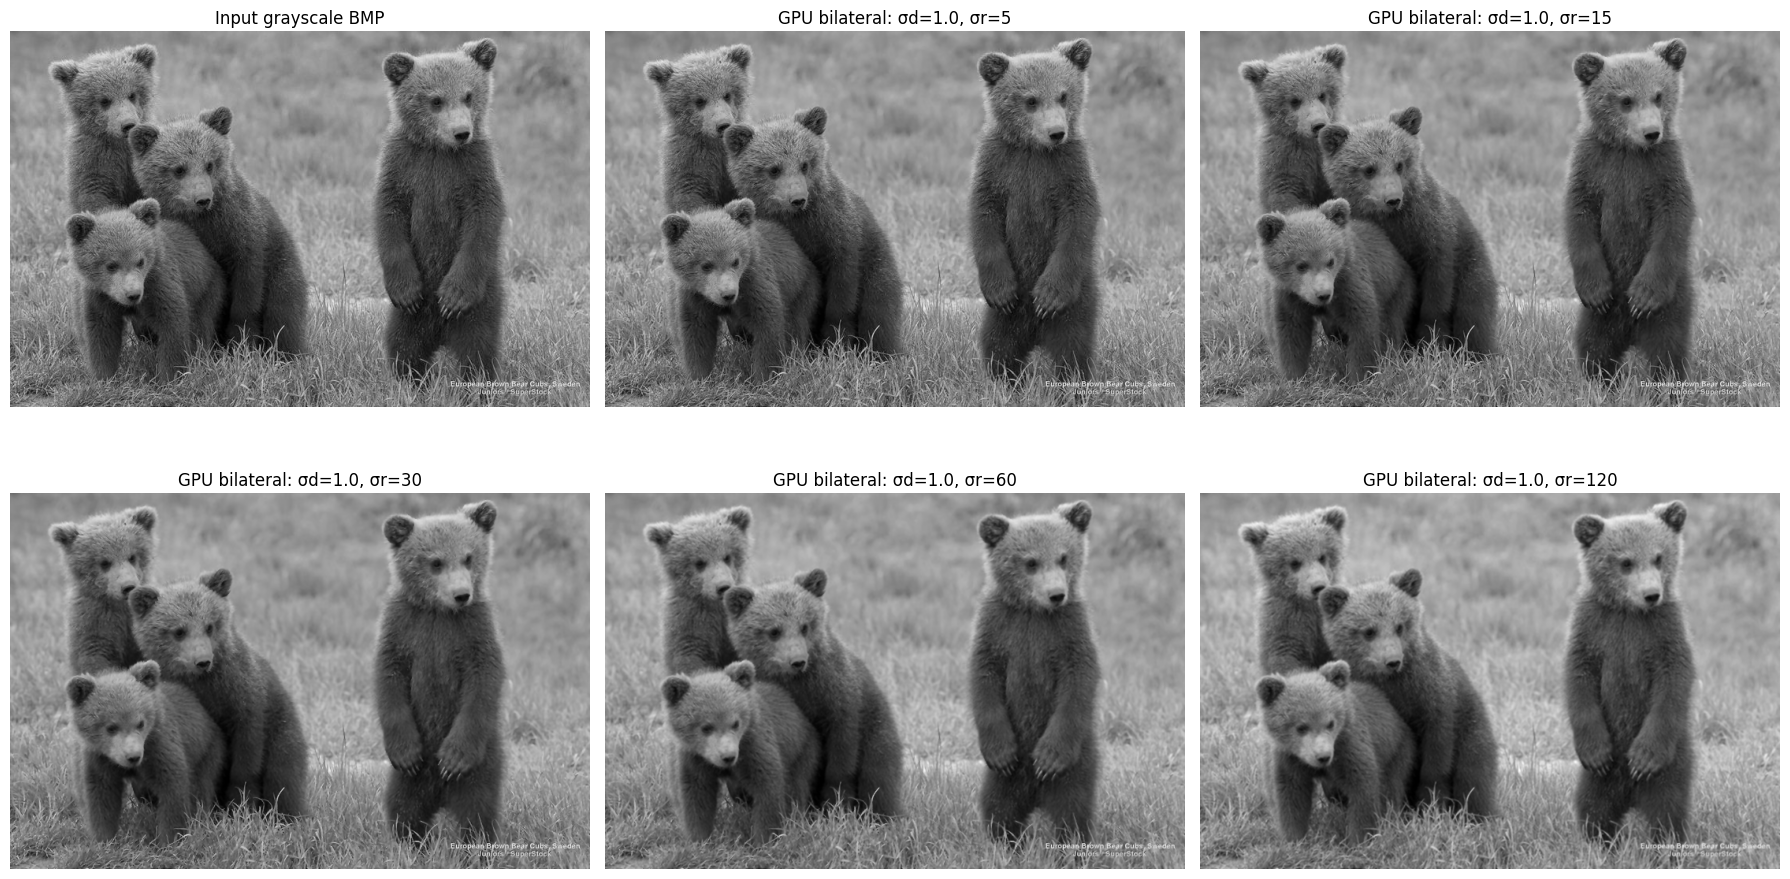

In [10]:
show_results_for_image("image_2")

### Общая таблица результатов и загрузка архива

In [11]:
make_final_archive()

,image,width,height,pixels,sigma_d,sigma_r,gpu_warmup_runs,gpu_measured_runs,"CPU time, ms","GPU setup + H2D, ms","GPU kernel avg, ms","GPU kernel min, ms","GPU kernel max, ms","GPU kernel std, ms","GPU D2H, ms","GPU estimated total, ms",kernel speedup,estimated total speedup,max abs diff,mean abs diff
0,image_1,1600,2400,3840000,1.0,5.0,3,20,513.207928,187.671795,0.519722,0.518176,0.524256,0.001362,0.959567,189.151084,987.466238,2.713217,1,0.000002
1,image_1,1600,2400,3840000,1.0,15.0,3,20,511.361093,152.791695,0.344342,0.342016,0.362496,0.004419,0.970240,154.106277,1485.038401,3.318237,1,0.000001
2,image_1,1600,2400,3840000,1.0,30.0,3,20,770.928335,164.440690,0.496170,0.495264,0.498432,0.000852,1.019373,165.956233,1553.758460,4.645371,1,0.000001
3,image_1,1600,2400,3840000,1.0,60.0,3,20,833.798477,173.223770,0.524845,0.521184,0.528192,0.001564,1.038907,174.787522,1588.656607,4.770355,1,0.000001
4,image_1,1600,2400,3840000,1.0,120.0,3,20,511.516875,166.797294,0.452506,0.450912,0.454656,0.000872,1.031533,168.281333,1130.409044,3.039653,1,0.000000
5,image_2,736,477,351072,1.0,5.0,3,20,72.816850,180.920227,0.056091,0.055296,0.057696,0.000748,0.134509,181.110827,1298.191332,0.402057,1,0.000003
6,image_2,736,477,351072,1.0,15.0,3,20,72.228794,162.121450,0.036403,0.034816,0.037248,0.000705,0.132043,162.289896,1984.143999,0.445060,1,0.000003
7,image_2,736,477,351072,1.0,30.0,3,20,71.132869,160.257188,0.032443,0.031168,0.033280,0.000509,0.142129,160.431760,2192.549055,0.443384,0,0.000000
8,image_2,736,477,351072,1.0,60.0,3,20,72.523938,166.184028,0.033221,0.032384,0.035328,0.000818,0.136614,166.353863,2183.075103,0.435962,0,0.000000
9,image_2,736,477,351072,1.0,120.0,3,20,45.076712,131.661563,0.031333,0.030720,0.032608,0.000704,0.123805,131.816701,1438.633773,0.341965,1,0.000003


В архив добавлены файлы:
  bilateral_filter.cu
  input_image_1.bmp
  input_image_2.bmp
  output_cpu_image_1_sd1.0_sr120.bmp
  output_cpu_image_1_sd1.0_sr15.bmp
  output_cpu_image_1_sd1.0_sr30.bmp
  output_cpu_image_1_sd1.0_sr5.bmp
  output_cpu_image_1_sd1.0_sr60.bmp
  output_cpu_image_2_sd1.0_sr120.bmp
  output_cpu_image_2_sd1.0_sr15.bmp
  output_cpu_image_2_sd1.0_sr30.bmp
  output_cpu_image_2_sd1.0_sr5.bmp
  output_cpu_image_2_sd1.0_sr60.bmp
  output_gpu_image_1_sd1.0_sr120.bmp
  output_gpu_image_1_sd1.0_sr15.bmp
  output_gpu_image_1_sd1.0_sr30.bmp
  output_gpu_image_1_sd1.0_sr5.bmp
  output_gpu_image_1_sd1.0_sr60.bmp
  output_gpu_image_2_sd1.0_sr120.bmp
  output_gpu_image_2_sd1.0_sr15.bmp
  output_gpu_image_2_sd1.0_sr30.bmp
  output_gpu_image_2_sd1.0_sr5.bmp
  output_gpu_image_2_sd1.0_sr60.bmp
  results_all.csv
  results_image_1.csv
  results_image_2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>